PC Graph Causal Discovery (causal-learn)

Input data sample:
         V0        V1        V2        V3        V4        V5
0  1.049521  1.049816  1.110538  1.029217  0.881840  0.996112
1  1.521042  1.541682  1.215752  1.281879  1.585992  1.574918
2  1.118939  1.024195  1.315607  1.088002  1.205775  1.326749
3  2.222301  2.236795  2.077927  2.373233  2.456400  2.219461
4  1.741151  1.704540  2.181352  1.736620  1.912772  1.779224

Data shape:
(1000, 6)

Variables:
['V0', 'V1', 'V2', 'V3', 'V4', 'V5']

True adjacency matrix:
     V0   V1   V2   V3   V4   V5
V0  0.0  1.0  1.0  0.0  1.0  0.0
V1  0.0  0.0  0.0  1.0  0.0  1.0
V2  0.0  0.0  0.0  0.0  1.0  1.0
V3  0.0  0.0  0.0  0.0  1.0  0.0
V4  0.0  0.0  0.0  0.0  0.0  0.0
V5  0.0  0.0  0.0  0.0  0.0  0.0

Predicted edges:
[('V0', 'V1'), ('V1', 'V0'), ('V1', 'V3'), ('V1', 'V5'), ('V2', 'V4'), ('V2', 'V5'), ('V4', 'V2'), ('V4', 'V3')]

Predicted adjacency matrix:
    V0  V1  V2  V3  V4  V5
V0   0   1   0   0   0   0
V1   1   0   0   1   0   1

/home/km1612@students.ad.unt.edu/projects/llm-causality-test/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/tmp/ipykernel_3313926/3959137061.py:89: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


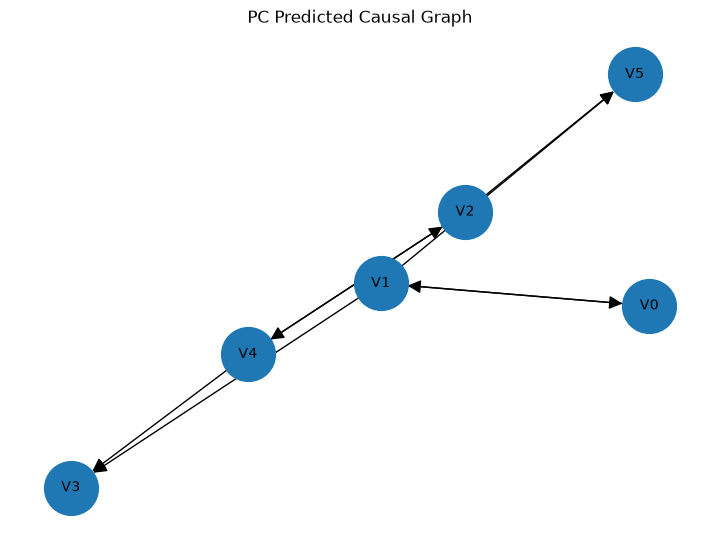


Comparison summary:
True edges: 8
Correctly predicted edges: 5
False positives: 3
False negatives: 3
Edge recall: 0.62
SHD: 6

Done.


In [1]:
import os
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from causallearn.search.ConstraintBased.PC import pc

OUTPUT_DIR = "cdt_outputs"
DATA_PATH = os.path.join(OUTPUT_DIR, "generated_graph_data.csv")
TARGET_PATH = os.path.join(OUTPUT_DIR, "generated_graph_target.csv")

def load_data():
    data = pd.read_csv(DATA_PATH)

    print("\nInput data sample:")
    print(data.head())

    print("\nData shape:")
    print(data.shape)

    print("\nVariables:")
    print(data.columns.tolist())

    return data


def load_true_adjacency(columns):
    true_adj = pd.read_csv(TARGET_PATH)

    true_adj.index = columns
    true_adj.columns = columns

    print("\nTrue adjacency matrix:")
    print(true_adj)

    return true_adj


def run_pc(data):
    columns = data.columns.tolist()

    cg = pc(data.values, alpha=0.05, indep_test='fisherz', show_progress=False)
    adj = cg.G.graph

    graph = nx.DiGraph()
    graph.add_nodes_from(columns)

    for i in range(len(columns)):
        for j in range(len(columns)):
            if i == j:
                continue
            # causal-learn encoding: adj[j, i]==1 and adj[i, j]==-1 means i --> j
            if adj[j, i] == 1 and adj[i, j] == -1:
                graph.add_edge(columns[i], columns[j])
            # both -1 means an undirected edge in the CPDAG; keep both directions
            elif adj[i, j] == -1 and adj[j, i] == -1:
                graph.add_edge(columns[i], columns[j])

    print("\nPredicted edges:")
    print(list(graph.edges()))

    return graph


def get_adjacency(graph, columns):
    return nx.to_pandas_adjacency(
        graph,
        nodelist=columns,
        dtype=int
    )


def show_graph(graph, title):
    plt.figure(figsize=(7, 5))

    pos = nx.spring_layout(graph, seed=42)

    nx.draw(
        graph,
        pos,
        with_labels=True,
        node_size=1500,
        arrows=True,
        arrowsize=20,
        font_size=10
    )

    plt.title(title)
    plt.tight_layout()
    plt.show()


def compare_graphs(true_adj, pred_adj):
    variables = list(pred_adj.columns)

    true_edges = 0
    correct_edges = 0
    false_positive = 0
    false_negative = 0

    for source in variables:
        for target in variables:

            if source == target:
                continue

            true_value = int(true_adj.loc[source, target])
            pred_value = int(pred_adj.loc[source, target])

            if true_value == 1:
                true_edges += 1

            if true_value == 1 and pred_value == 1:
                correct_edges += 1
            elif true_value == 0 and pred_value == 1:
                false_positive += 1
            elif true_value == 1 and pred_value == 0:
                false_negative += 1

    recall = correct_edges / true_edges if true_edges > 0 else 0

    # Structural Hamming Distance: number of differing entries between
    # the true and predicted adjacency matrices.
    shd_score = int(np.abs(true_adj.values - pred_adj.values).sum())

    print("\nComparison summary:")
    print(f"True edges: {true_edges}")
    print(f"Correctly predicted edges: {correct_edges}")
    print(f"False positives: {false_positive}")
    print(f"False negatives: {false_negative}")
    print(f"Edge recall: {recall:.2f}")
    print(f"SHD: {shd_score}")


def main():
    print("========================================")
    print("PC Graph Causal Discovery (causal-learn)")
    print("========================================")

    data = load_data()
    columns = data.columns.tolist()

    true_adj = load_true_adjacency(columns)

    pred_graph = run_pc(data)

    pred_adj = get_adjacency(pred_graph, columns)

    print("\nPredicted adjacency matrix:")
    print(pred_adj)

    show_graph(pred_graph, "PC Predicted Causal Graph")

    compare_graphs(true_adj, pred_adj)

    print("\nDone.")


if __name__ == "__main__":
    main()

## PC Causal Discovery Algorithm (Sachs benchmark graph dataset)

Detecting 1 CUDA device(s).


CDT-PC on Sachs Dataset

Input data sample:
   praf  pmek   plcg   PIP2   PIP3  p44/42  pakts473    PKA    PKC   P38  pjnk
0  26.4  13.2   8.82  18.30  58.80    6.61      17.0  414.0  17.00  44.9  40.0
1  35.9  16.5  12.30  16.80   8.13   18.60      32.5  352.0   3.37  16.5  61.5
2  59.4  44.1  14.60  10.20  13.00   14.90      32.5  403.0  11.40  31.9  19.5
3  73.0  82.8  23.10  13.50   1.29    5.83      11.8  528.0  13.70  28.6  23.1
4  33.7  19.8   5.19   9.73  24.80   21.10      46.1  305.0   4.66  25.7  81.3

Data shape:
(7466, 11)

Variables:
['praf', 'pmek', 'plcg', 'PIP2', 'PIP3', 'p44/42', 'pakts473', 'PKA', 'PKC', 'P38', 'pjnk']

True adjacency matrix:
          praf  pmek  plcg  PIP2  PIP3  p44/42  pakts473  PKA  PKC  P38  pjnk
praf       0.0   1.0   0.0   0.0   0.0     0.0       0.0  0.0  0.0  0.0   0.0
pmek       0.0   0.0   0.0   0.0   0.0     1.0       0.0  0.0  0.0  0.0   0.0
plcg       0.0   0.0   0.0   1.0   0.0     0.0       0.0  0.0  1.0  0.0   0.0
PIP2       0.0   0

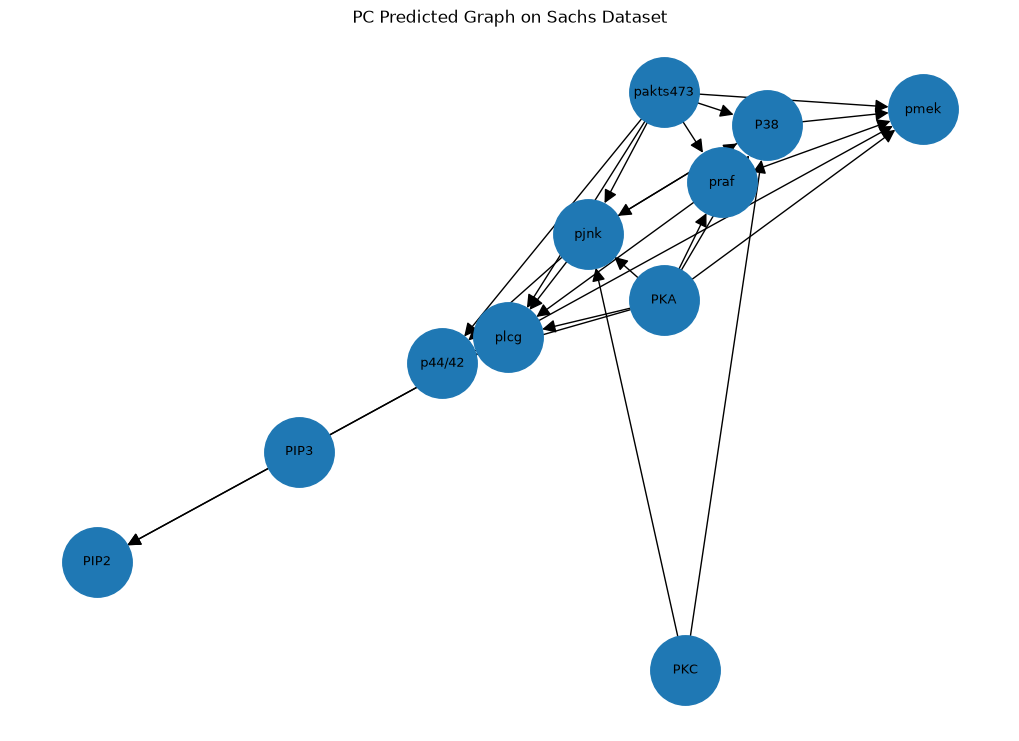


Comparison summary:
True edges: 18
Predicted edges: 26
SHD: 24

Done.


In [7]:
import os
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from causallearn.search.ConstraintBased.PC import pc
from sklearn.preprocessing import StandardScaler
from cdt.metrics import SHD

DATA_PATH = "cdt_outputs/sachs_data.csv"
TARGET_PATH = "cdt_outputs/sachs_target_adjacency.csv"


def load_data():
    data = pd.read_csv(DATA_PATH).dropna().copy()

    print("\nInput data sample:")
    print(data.head())

    print("\nData shape:")
    print(data.shape)

    print("\nVariables:")
    print(data.columns.tolist())

    return data


def standardize_data(data):
    scaler = StandardScaler()

    data_scaled = pd.DataFrame(
        scaler.fit_transform(data),
        columns=data.columns
    )

    return data_scaled


def load_true_adjacency(columns):
    true_adj = pd.read_csv(TARGET_PATH, index_col=0)

    # Match row/column order with data columns
    true_adj = true_adj.loc[columns, columns]

    print("\nTrue adjacency matrix:")
    print(true_adj)

    return true_adj


def run_pc(data_scaled):
    columns = data_scaled.columns.tolist()

    cg = pc(
        data_scaled.values,
        alpha=0.05,
        indep_test="fisherz",
        show_progress=False
    )

    adj = cg.G.graph
    graph = nx.DiGraph()
    graph.add_nodes_from(columns)

    for i in range(len(columns)):
        for j in range(len(columns)):
            if i == j:
                continue

            if adj[j, i] == 1 and adj[i, j] == -1:
                graph.add_edge(columns[i], columns[j])
            elif adj[i, j] == -1 and adj[j, i] == -1:
                graph.add_edge(columns[i], columns[j])

    return graph


def get_adjacency(graph, columns):
    adj = nx.to_pandas_adjacency(
        graph,
        nodelist=columns,
        dtype=int
    )

    print("\nPredicted adjacency matrix:")
    print(adj)

    return adj


def adjacency_to_graph(adj):
    graph = nx.DiGraph()
    graph.add_nodes_from(adj.index)

    for source in adj.index:
        for target in adj.columns:
            if int(adj.loc[source, target]) == 1:
                graph.add_edge(source, target)

    return graph


def show_graph(graph, title):
    plt.figure(figsize=(10, 7))

    pos = nx.spring_layout(graph, seed=42)

    nx.draw(
        graph,
        pos,
        with_labels=True,
        node_size=2500,
        arrows=True,
        arrowsize=20,
        font_size=9
    )

    plt.title(title)
    plt.axis("off")
    plt.subplots_adjust(left=0.05, right=0.95, top=0.90, bottom=0.05)
    plt.show()


def compare_graphs(true_adj, pred_adj):
    columns = pred_adj.columns.tolist()

    true_graph = adjacency_to_graph(true_adj)
    pred_graph = adjacency_to_graph(pred_adj)

    shd_score = SHD(true_graph, pred_graph)

    true_edges = int(true_adj.values.sum())
    pred_edges = int(pred_adj.values.sum())

    print("\nComparison summary:")
    print(f"True edges: {true_edges}")
    print(f"Predicted edges: {pred_edges}")
    print(f"SHD: {shd_score}")


def main():
    print("========================================")
    print("CDT-PC on Sachs Dataset")
    print("========================================")

    data = load_data()
    columns = data.columns.tolist()

    data_scaled = standardize_data(data)

    true_adj = load_true_adjacency(columns)

    pred_graph = run_pc(data_scaled)

    pred_adj = get_adjacency(pred_graph, columns)

    show_graph(pred_graph, "PC Predicted Graph on Sachs Dataset")

    compare_graphs(true_adj, pred_adj)

    print("\nDone.")

if __name__ == "__main__":
    main()

## PC Causal Discovery Algorithm (Real Time Series AQI Data)

CDT-PC Graph Causal Discovery
Real Multipollutant Dataset

Input data sample:
   pm25     ozone   T2M   RH2M  PRECTOTCORR  WS2M
0   2.1  0.031333  2.87  86.58         1.92  4.01
1   3.3  0.032000  2.89  77.71         0.16  2.45
2   4.8  0.035667  5.52  73.90         0.31  2.91
3  11.4  0.034000  8.32  71.72         0.00  1.53
4   9.7  0.034667  8.45  75.69         0.00  2.07

Data shape:
(1826, 6)

Variables:
['pm25', 'ozone', 'T2M', 'RH2M', 'PRECTOTCORR', 'WS2M']

Standardized data sample:
       pm25     ozone       T2M      RH2M  PRECTOTCORR      WS2M
0 -1.592597 -0.697224 -1.772535  1.399228    -0.061654  0.832728
1 -1.323068 -0.647569 -1.770426  0.813582    -0.330056 -0.407216
2 -0.986156 -0.374467 -1.493161  0.562026    -0.307181 -0.041592
3  0.496255 -0.498604 -1.197973  0.418090    -0.354457 -1.138466
4  0.114422 -0.448950 -1.184268  0.680211    -0.354457 -0.709254

Predicted adjacency matrix:
             pm25  ozone  T2M  RH2M  PRECTOTCORR  WS2M
pm25            0      0    0 

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


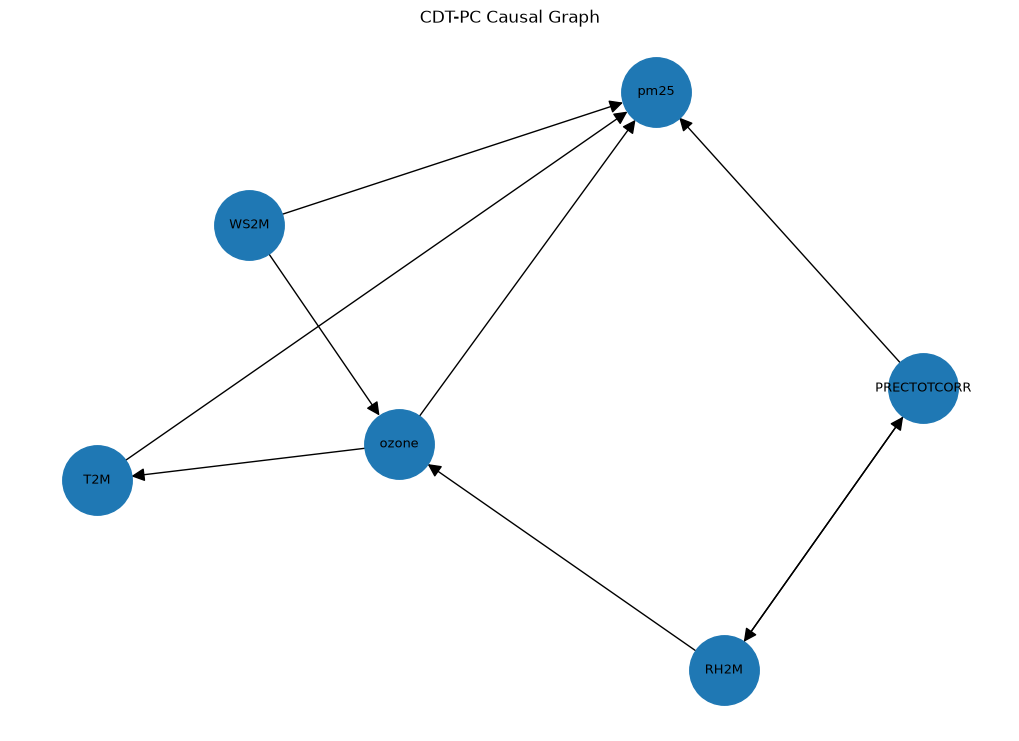


Done.


In [8]:
import os
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from causallearn.search.ConstraintBased.PC import pc
from sklearn.preprocessing import StandardScaler
from cdt.metrics import SHD


DATA_PATH = "datasets/multipollutants_dallas_combined_with_Meteorology.csv"

COLS = [
    "pm25",
    "ozone",
    "T2M",
    "RH2M",
    "PRECTOTCORR",
    "WS2M",
]

def load_data():
    df = pd.read_csv(DATA_PATH)

    data = df[COLS].dropna().copy()

    print("\nInput data sample:")
    print(data.head())

    print("\nData shape:")
    print(data.shape)

    print("\nVariables:")
    print(data.columns.tolist())

    return data


def standardize_data(data):
    scaler = StandardScaler()

    data_scaled = pd.DataFrame(
        scaler.fit_transform(data),
        columns=data.columns
    )

    print("\nStandardized data sample:")
    print(data_scaled.head())

    return data_scaled


def run_pc(data_scaled):
    columns = data_scaled.columns.tolist()

    cg = pc(
        data_scaled.values,
        alpha=0.05,
        indep_test="fisherz",
        show_progress=False
    )

    adj = cg.G.graph
    graph = nx.DiGraph()
    graph.add_nodes_from(columns)

    for i in range(len(columns)):
        for j in range(len(columns)):
            if i == j:
                continue

            if adj[j, i] == 1 and adj[i, j] == -1:
                graph.add_edge(columns[i], columns[j])
            elif adj[i, j] == -1 and adj[j, i] == -1:
                graph.add_edge(columns[i], columns[j])

    return graph


def get_adjacency(graph, columns):
    adj = nx.to_pandas_adjacency(
        graph,
        nodelist=columns,
        dtype=int
    )

    print("\nPredicted adjacency matrix:")
    print(adj)

    return adj


def show_graph(graph, title="CDT-PC Causal Graph"):
    plt.figure(figsize=(10, 7))

    pos = nx.spring_layout(graph, seed=42)

    nx.draw(
        graph,
        pos,
        with_labels=True,
        node_size=2500,
        arrows=True,
        arrowsize=20,
        font_size=9
    )

    plt.title(title)
    plt.axis("off")
    plt.tight_layout()
    plt.show()


def main():
    print("========================================")
    print("CDT-PC Graph Causal Discovery")
    print("Real Multipollutant Dataset")
    print("========================================")

    data = load_data()

    data_scaled = standardize_data(data)

    pc_graph = run_pc(data_scaled)

    pred_adj = get_adjacency(
        pc_graph,
        columns=data_scaled.columns.tolist()
    )

    show_graph(pc_graph)

    print("\nDone.")


if __name__ == "__main__":
    main()